In [1]:
from layertrak.data import get_dataloaders
from layertrak.settings import settings

# LayerTRAK — Notebook demo

Quickstart: train models on CIFAR-10, compute per-layer TRAK scores, visualize results.
Uses modules from `layertrak` package.

In [2]:
print(f"Device: {settings.device}")
print(f"Batch size: {settings.batch_size}")
print(f"Epochs: {settings.num_epochs}")
print(f"TRAK proj_dim: {settings.trak_proj_dim}")

Device: mps
Batch size: 128
Epochs: 5
TRAK proj_dim: 1024


## 1. Data preparation

In [3]:
train_loader, test_loader, targets_loader = get_dataloaders()
print(f"Train: {len(train_loader.dataset)}, Test: {len(test_loader.dataset)}, Targets: {len(targets_loader.dataset)}")

/Users/mateusz/PW/SIWY/LayerTRAK/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000, Test: 10000, Targets: 1000


## 2. Create model & visualize architecture

In [4]:

from layertrak.models import create_model 
model = create_model("resnet18", device=settings.device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Total params: {total:,} | Trainable (layer4+fc): {trainable:,} ({trainable / total:.1%})")

# Show layer structure
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  [trainable] {name}: {param.shape}")


Total params: 11,181,642 | Trainable (layer4+fc): 8,398,858 (75.1%)
  [trainable] layer4.0.conv1.weight: torch.Size([512, 256, 3, 3])
  [trainable] layer4.0.bn1.weight: torch.Size([512])
  [trainable] layer4.0.bn1.bias: torch.Size([512])
  [trainable] layer4.0.conv2.weight: torch.Size([512, 512, 3, 3])
  [trainable] layer4.0.bn2.weight: torch.Size([512])
  [trainable] layer4.0.bn2.bias: torch.Size([512])
  [trainable] layer4.0.downsample.0.weight: torch.Size([512, 256, 1, 1])
  [trainable] layer4.0.downsample.1.weight: torch.Size([512])
  [trainable] layer4.0.downsample.1.bias: torch.Size([512])
  [trainable] layer4.1.conv1.weight: torch.Size([512, 512, 3, 3])
  [trainable] layer4.1.bn1.weight: torch.Size([512])
  [trainable] layer4.1.bn1.bias: torch.Size([512])
  [trainable] layer4.1.conv2.weight: torch.Size([512, 512, 3, 3])
  [trainable] layer4.1.bn2.weight: torch.Size([512])
  [trainable] layer4.1.bn2.bias: torch.Size([512])
  [trainable] fc.weight: torch.Size([10, 512])
  [trainab

## 3. Training loop

In [5]:
from layertrak.models import train_model
checkpoint = train_model(
    model, train_loader, test_loader,
    device=settings.device,
    run_name="resnet18_demo",
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/mateusz/.netrc.
wandb: Currently logged in as: matthev00 (MY_EXPERIMENTS) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/5 — train_loss: 1.5087, train_acc: 0.4678, test_loss: 1.2834, test_acc: 0.5521


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x119974830>> (for post_run_cell), with arguments args (<ExecutionResult object at 118505e10, execution_count=5 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 11986ead0, raw_cell="from layertrak.models import train_model
checkpoin.." transformed_cell="from layertrak.models import train_model
checkpoin.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/mateusz/PW/SIWY/LayerTRAK/notebooks/initial.ipynb#X66sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## 4. TRAK on selected layers (`grad_wrt`)

Porównanie TRAK scores przy ograniczeniu gradientów do wybranych warstw ResNet-18.
`TRAKer` wspiera parametr `grad_wrt` — lista nazw parametrów, po których liczone są gradienty.

Konfiguracje:
- **Head-only:** tylko `fc` (warstwa liniowa)
- **Late:** `layer4` + `fc`
- **Mid+Late:** `layer3` + `layer4` + `fc`

In [6]:
import numpy as np
from layertrak.experiments import LayerTRAKRunner
from layertrak.models import get_layer_configs, get_grad_wrt

layer_configs = get_layer_configs("resnet18")[0:1]
train_set_size = len(train_loader.dataset)
layer_scores: dict[str, np.ndarray] = {}

for config in layer_configs:
    name = config["name"]
    grad_wrt = get_grad_wrt(model, config["prefixes"])
    num_params = sum(p.numel() for n, p in model.named_parameters() if n in grad_wrt)
    print(f"\n{'=' * 60}")
    print(f"Config: {name} | params tracked: {num_params:,} | prefixes: {config['prefixes']}")

    runner = LayerTRAKRunner(
        model=model,
        checkpoint=checkpoint,
        train_set_size=train_set_size,
        save_dir=settings.project_root / settings.trak_results_dir / f"resnet18_{name}",
        device=settings.device,
        grad_wrt=grad_wrt,
    )
    runner.featurize(train_loader)
    scores = runner.score(targets_loader, num_targets=settings.num_targets, exp_name=name)
    layer_scores[name] = scores
    print(f"  Scores shape: {scores.shape}")

print("\nDone!")


INFO:TRAK:Using BasicProjector since device is CPU
INFO:TRAK:Using Normal projection
INFO:STORE:No existing model IDs in /Users/mateusz/PW/SIWY/LayerTRAK/trak_results/resnet18_head_only.
INFO:STORE:No existing TRAK scores in /Users/mateusz/PW/SIWY/LayerTRAK/trak_results/resnet18_head_only.



Config: head_only | params tracked: 5,130 | prefixes: ['fc.']


Finalizing scores for all model IDs..: 100%|██████████| 1/1 [00:01<00:00,  1.10s/it]
INFO:STORE:Saving scores in /Users/mateusz/PW/SIWY/LayerTRAK/trak_results/resnet18_head_only/scores/head_only.mmap


  Scores shape: (50000, 1000)

Done!


## 5. Wizualizacja wyników TRAK
Top-10 najbardziej wpływowych próbek treningowych dla wybranego targetu.

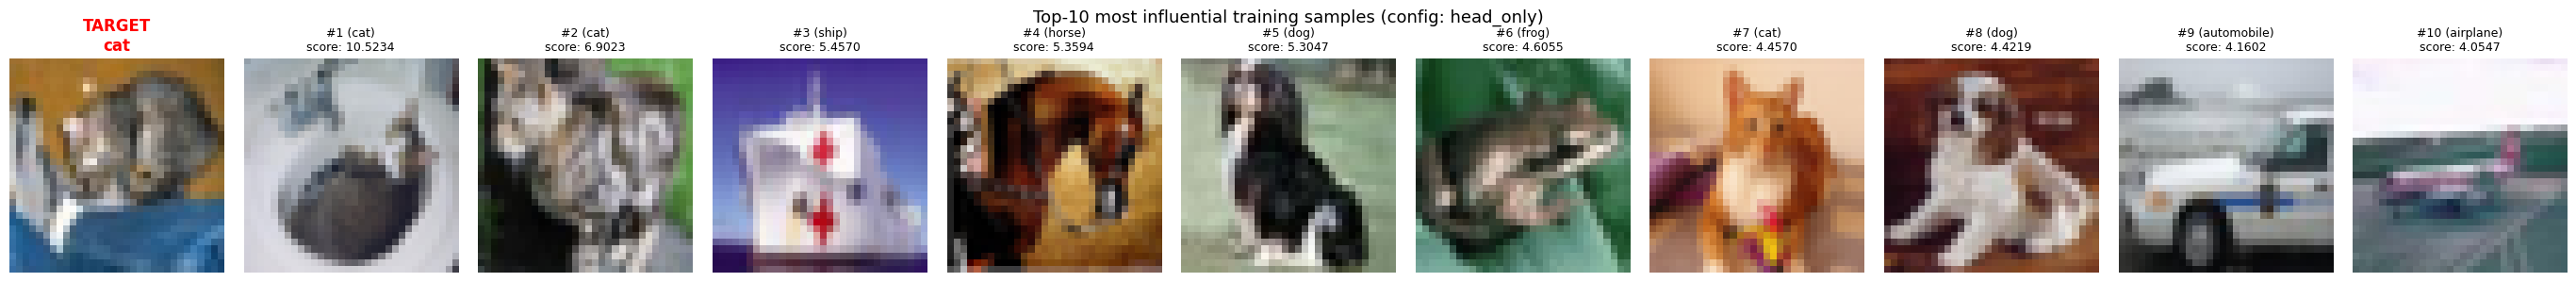

In [12]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Load raw CIFAR-10 (without normalization) for display
raw_dataset = datasets.CIFAR10(
    root=str(settings.project_root / settings.data_dir),
    train=True, download=False,
    transform=transforms.ToTensor(),
)
raw_test = datasets.CIFAR10(
    root=str(settings.project_root / settings.data_dir),
    train=False, download=False,
    transform=transforms.ToTensor(),
)
CLASSES = raw_dataset.classes

# Pick first config's scores
config_name = list(layer_scores.keys())[0]
scores = layer_scores[config_name]  # (num_targets, train_size)

# Choose a target sample
TARGET_IDX = 0
target_scores = scores[TARGET_IDX]

# Top-10 most influential training samples
top_k = 10
top_indices = np.argsort(target_scores)[-top_k:][::-1]

fig, axes = plt.subplots(1, top_k + 1, figsize=(2.5 * (top_k + 1), 3))

# Show target
img, label = raw_test[TARGET_IDX]
axes[0].imshow(img.permute(1, 2, 0))
axes[0].set_title(f"TARGET\n{CLASSES[label]}", fontweight="bold", color="red")
axes[0].axis("off")

# Show top-k influential training samples
for i, idx in enumerate(top_indices):
    img, label = raw_dataset[idx]
    ax = axes[i + 1]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"#{i+1} ({CLASSES[label]})\nscore: {target_scores[idx]:.4f}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Top-{top_k} most influential training samples (config: {config_name})", fontsize=13)
plt.tight_layout()
plt.show()